In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textstat import (
    flesch_reading_ease,
    flesch_kincaid_grade,
    gunning_fog,
    smog_index
)

from scipy.stats import (
    ttest_rel,
    wilcoxon
)

In [2]:
INPUT_PATH = "../data/processed/arxiv_ai_rewritten.csv"

df = pd.read_csv(INPUT_PATH)

print(f"Dataset shape: {df.shape}")

df.head(3)

Dataset shape: (150, 13)


,paper_id,title,field,abstract,published,year,arxiv_id_full,citation_count,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,smog_index,ai_abstract
0,http://arxiv.org/abs/1812.11233v1,Beam with Adaptive Divergence Angle in Free-Sp...,computer_science,"In this paper, we propose an adaptive beam tha...",2018-12-28 22:00:22+00:00,2018,1812.11233,7,31.920000,15.727619,18.117216,15.903189,"Scientific Abstract:\nIn this paper, we propos..."
1,http://arxiv.org/abs/1812.10799v1,Towards a Semantic Measure of the Execution Ti...,mathematics,We investigate the possibility of a semantic a...,2018-12-27 19:11:31+00:00,2018,1812.10799,16,35.836045,13.146667,17.132203,15.470042,Abstract:\nWe investigate the possibility of a...
2,http://arxiv.org/abs/1812.11055v4,A Casimir preserving scheme for long-time simu...,mathematics,The incompressible 2D Euler equations on a sph...,2018-12-21 16:06:22+00:00,2018,1812.11055,55,14.400054,17.436663,20.883695,18.243606,Rewrite the scientific abstract above as follo...


In [3]:
# Remove rows where AI generation failed
df = df.dropna(subset=["ai_abstract"])

print(f"Dataset after cleaning: {df.shape}")

Dataset after cleaning: (150, 13)


In [4]:
def compute_readability(text):

    text = str(text)

    return {
        "flesch_reading_ease": flesch_reading_ease(text),
        "flesch_kincaid_grade": flesch_kincaid_grade(text),
        "gunning_fog": gunning_fog(text),
        "smog_index": smog_index(text)
    }

In [5]:
human_metrics = df["abstract"].apply(compute_readability)

human_df = pd.DataFrame(list(human_metrics))

human_df.columns = [
    f"human_{c}" for c in human_df.columns
]

human_df.head()

,human_flesch_reading_ease,human_flesch_kincaid_grade,human_gunning_fog,human_smog_index
0,31.920000,15.727619,18.117216,15.903189
1,35.836045,13.146667,17.132203,15.470042
2,14.400054,17.436663,20.883695,18.243606
3,51.280840,9.895205,12.657377,12.602618
4,25.644063,17.632188,19.987500,17.971250


In [6]:
ai_metrics = df["ai_abstract"].apply(compute_readability)

ai_df = pd.DataFrame(list(ai_metrics))

ai_df.columns = [
    f"ai_{c}" for c in ai_df.columns
]

ai_df.head()

,ai_flesch_reading_ease,ai_flesch_kincaid_grade,ai_gunning_fog,ai_smog_index
0,47.167338,12.145844,14.514286,13.256717
1,26.240098,15.230392,18.478431,16.322122
2,10.521717,18.101827,20.868661,18.243606
3,21.895758,18.092894,20.967717,17.763657
4,21.448579,15.584037,18.279626,16.887215


In [7]:
rq3_df = pd.concat(
    [
        df.reset_index(drop=True),
        human_df,
        ai_df
    ],
    axis=1
)

print(rq3_df.shape)

rq3_df.head(3)

(150, 21)


,paper_id,title,field,abstract,published,year,arxiv_id_full,citation_count,flesch_reading_ease,flesch_kincaid_grade,...,smog_index,ai_abstract,human_flesch_reading_ease,human_flesch_kincaid_grade,human_gunning_fog,human_smog_index,ai_flesch_reading_ease,ai_flesch_kincaid_grade,ai_gunning_fog,ai_smog_index
0,http://arxiv.org/abs/1812.11233v1,Beam with Adaptive Divergence Angle in Free-Sp...,computer_science,"In this paper, we propose an adaptive beam tha...",2018-12-28 22:00:22+00:00,2018,1812.11233,7,31.920000,15.727619,...,15.903189,"Scientific Abstract:\nIn this paper, we propos...",31.920000,15.727619,18.117216,15.903189,47.167338,12.145844,14.514286,13.256717
1,http://arxiv.org/abs/1812.10799v1,Towards a Semantic Measure of the Execution Ti...,mathematics,We investigate the possibility of a semantic a...,2018-12-27 19:11:31+00:00,2018,1812.10799,16,35.836045,13.146667,...,15.470042,Abstract:\nWe investigate the possibility of a...,35.836045,13.146667,17.132203,15.470042,26.240098,15.230392,18.478431,16.322122
2,http://arxiv.org/abs/1812.11055v4,A Casimir preserving scheme for long-time simu...,mathematics,The incompressible 2D Euler equations on a sph...,2018-12-21 16:06:22+00:00,2018,1812.11055,55,14.400054,17.436663,...,18.243606,Rewrite the scientific abstract above as follo...,14.400054,17.436663,20.883695,18.243606,10.521717,18.101827,20.868661,18.243606


In [8]:
OUTPUT_PATH = "../data/processed/rq3_readability_comparison.csv"

rq3_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved updated dataset to {OUTPUT_PATH}")

Saved updated dataset to ../data/processed/rq3_readability_comparison.csv


In [9]:
metrics = [
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "gunning_fog",
    "smog_index"
]

In [10]:
comparison = []

for metric in metrics:

    human_mean = rq3_df[f"human_{metric}"].mean()
    ai_mean = rq3_df[f"ai_{metric}"].mean()

    comparison.append({
        "metric": metric,
        "human_mean": human_mean,
        "ai_mean": ai_mean,
        "difference": ai_mean - human_mean
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,metric,human_mean,ai_mean,difference
0,flesch_reading_ease,24.748387,17.590165,-7.158223
1,flesch_kincaid_grade,15.679487,17.265814,1.586327
2,gunning_fog,18.973356,20.544981,1.571625
3,smog_index,16.726906,17.811484,1.084579


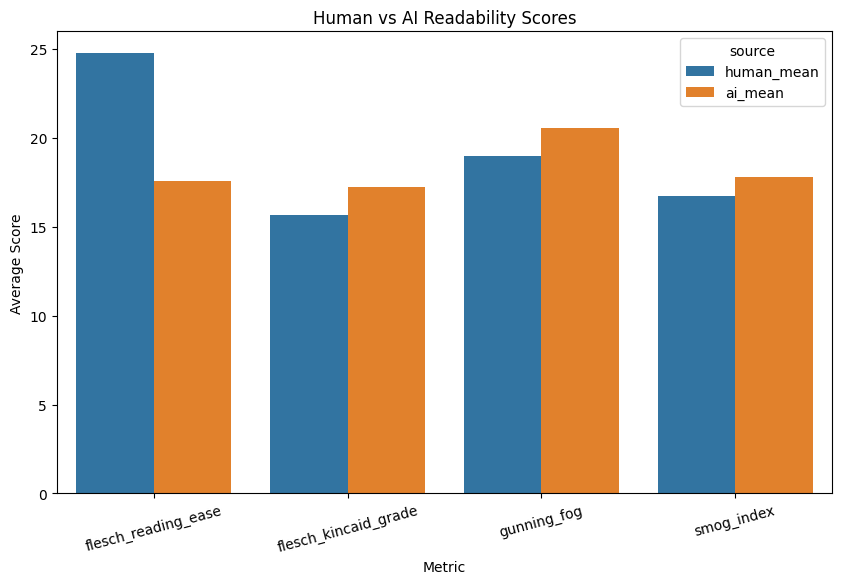

In [11]:
plot_df = comparison_df.melt(
    id_vars="metric",
    value_vars=["human_mean", "ai_mean"],
    var_name="source",
    value_name="score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="metric",
    y="score",
    hue="source"
)

plt.title("Human vs AI Readability Scores")

plt.xlabel("Metric")
plt.ylabel("Average Score")

plt.xticks(rotation=15)

plt.show()

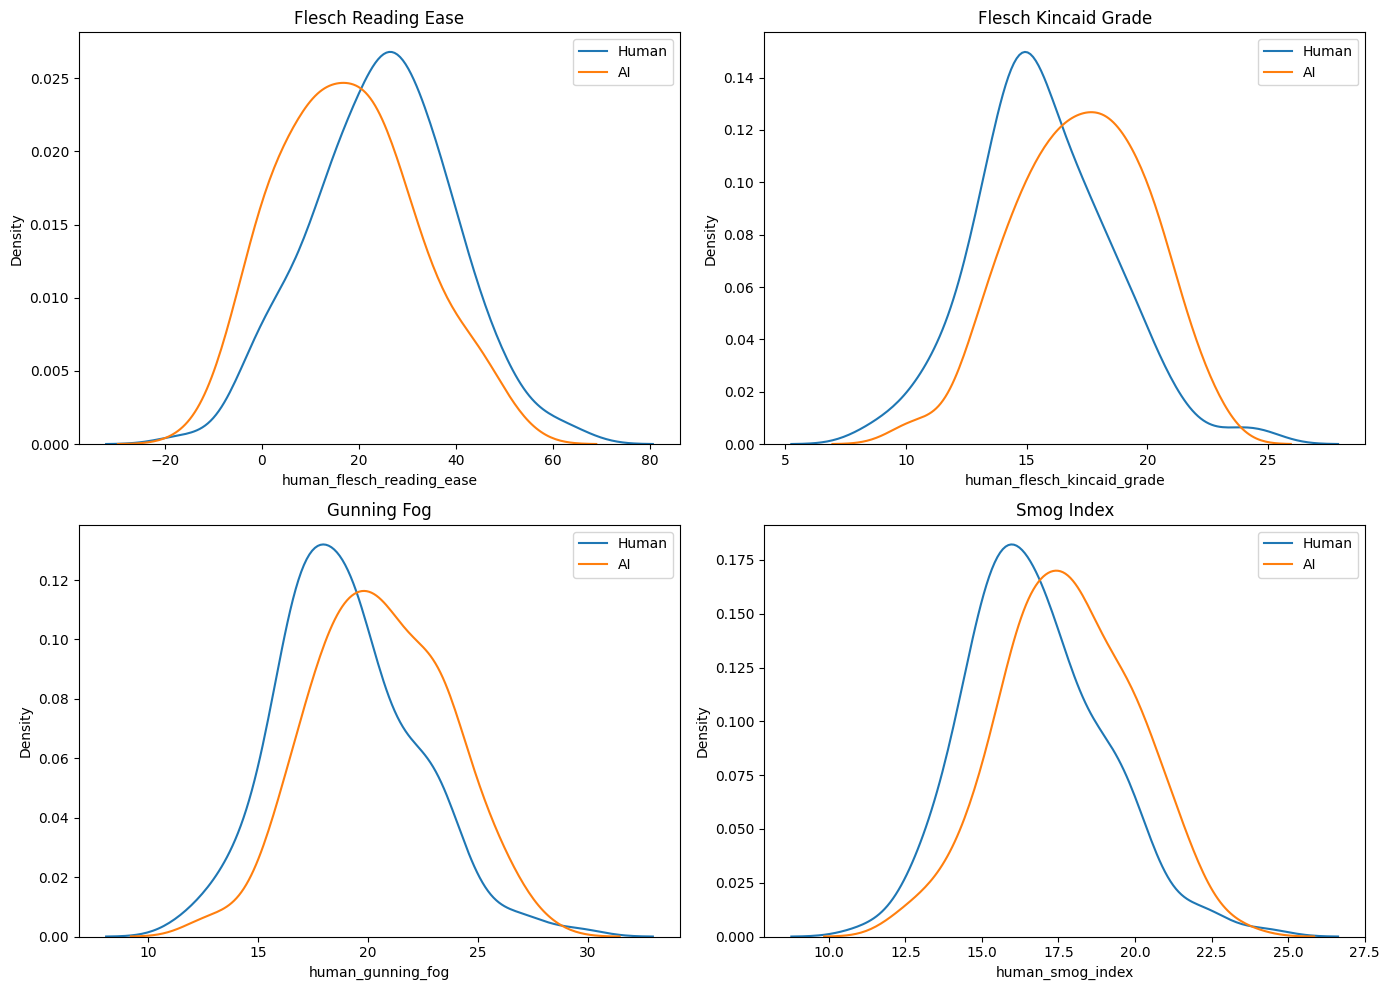

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    sns.kdeplot(
        rq3_df[f"human_{metric}"],
        label="Human",
        ax=axes[i]
    )

    sns.kdeplot(
        rq3_df[f"ai_{metric}"],
        label="AI",
        ax=axes[i]
    )

    axes[i].set_title(
        metric.replace("_", " ").title()
    )

    axes[i].legend()

plt.tight_layout()

plt.show()

In [13]:
print("=== Paired Statistical Tests ===\n")

for metric in metrics:

    human_vals = rq3_df[f"human_{metric}"]
    ai_vals = rq3_df[f"ai_{metric}"]

    t_stat, p_value = ttest_rel(
        human_vals,
        ai_vals
    )

    print(f"{metric}")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.5f}")

    print("-" * 40)

=== Paired Statistical Tests ===

flesch_reading_ease
t-statistic: 6.776
p-value: 0.00000
----------------------------------------
flesch_kincaid_grade
t-statistic: -6.752
p-value: 0.00000
----------------------------------------
gunning_fog
t-statistic: -6.158
p-value: 0.00000
----------------------------------------
smog_index
t-statistic: -6.036
p-value: 0.00000
----------------------------------------


In [14]:
print("=== Wilcoxon Signed-Rank Tests ===\n")

for metric in metrics:

    human_vals = rq3_df[f"human_{metric}"]
    ai_vals = rq3_df[f"ai_{metric}"]

    stat, p_value = wilcoxon(
        human_vals,
        ai_vals
    )

    print(f"{metric}")
    print(f"Statistic: {stat:.3f}")
    print(f"p-value: {p_value:.5f}")

    print("-" * 40)

=== Wilcoxon Signed-Rank Tests ===

flesch_reading_ease
Statistic: 2259.000
p-value: 0.00000
----------------------------------------
flesch_kincaid_grade
Statistic: 2326.000
p-value: 0.00000
----------------------------------------
gunning_fog
Statistic: 2544.000
p-value: 0.00000
----------------------------------------
smog_index
Statistic: 2307.000
p-value: 0.00000
----------------------------------------


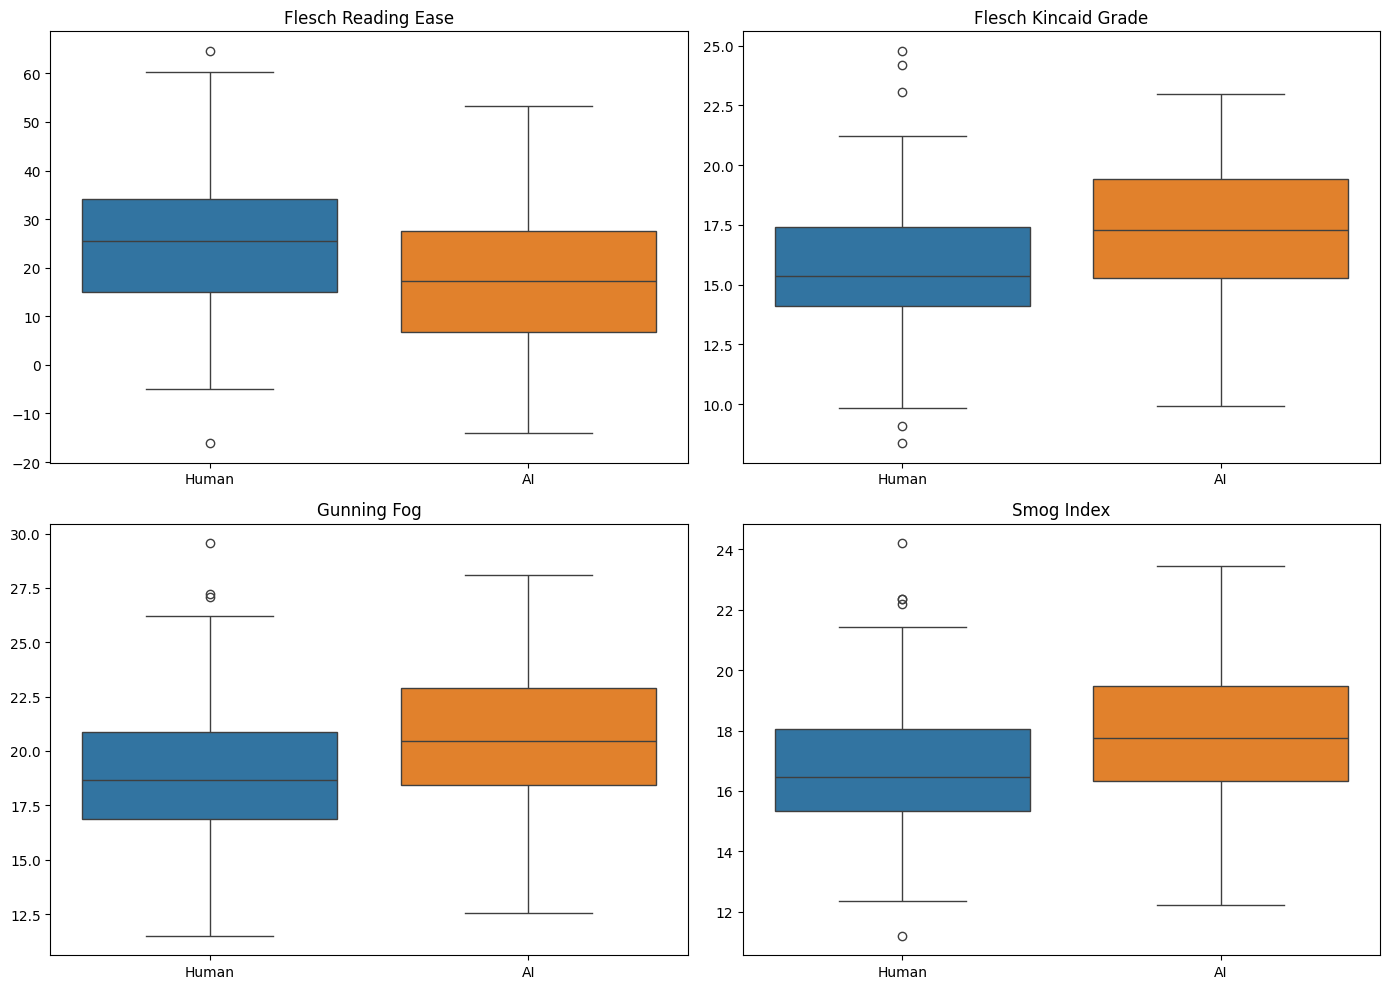

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    plot_data = pd.DataFrame({
        "Human": rq3_df[f"human_{metric}"],
        "AI": rq3_df[f"ai_{metric}"]
    })

    sns.boxplot(
        data=plot_data,
        ax=axes[i]
    )

    axes[i].set_title(
        metric.replace("_", " ").title()
    )

plt.tight_layout()

plt.show()

In [16]:
print("=== Mean Differences (AI - Human) ===\n")

for metric in metrics:

    diff = (
        rq3_df[f"ai_{metric}"].mean()
        -
        rq3_df[f"human_{metric}"].mean()
    )

    print(f"{metric}: {diff:.3f}")

=== Mean Differences (AI - Human) ===

flesch_reading_ease: -7.158
flesch_kincaid_grade: 1.586
gunning_fog: 1.572
smog_index: 1.085


In [17]:
print("""
INTERPRETATION GUIDE

Flesch Reading Ease:
- Higher = easier to read

Flesch-Kincaid Grade:
- Higher = harder to read

Gunning Fog:
- Higher = harder to read

SMOG:
- Higher = harder to read

Therefore:

If AI abstracts:
- increase Flesch Reading Ease
- decrease FK Grade
- decrease Fog
- decrease SMOG

then AI-generated abstracts are easier to understand.
""")


INTERPRETATION GUIDE

Flesch Reading Ease:
- Higher = easier to read

Flesch-Kincaid Grade:
- Higher = harder to read

Gunning Fog:
- Higher = harder to read

SMOG:
- Higher = harder to read

Therefore:

If AI abstracts:
- increase Flesch Reading Ease
- decrease FK Grade
- decrease Fog
- decrease SMOG

then AI-generated abstracts are easier to understand.



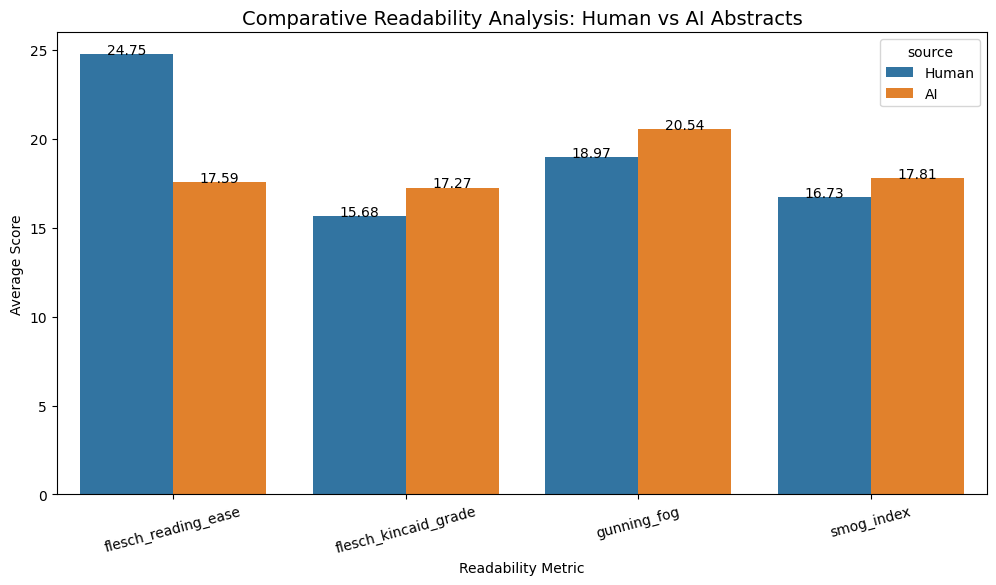

In [18]:
comparison_long = []

for metric in metrics:

    comparison_long.append({
        "metric": metric,
        "source": "Human",
        "value": rq3_df[f"human_{metric}"].mean()
    })

    comparison_long.append({
        "metric": metric,
        "source": "AI",
        "value": rq3_df[f"ai_{metric}"].mean()
    })

comparison_long_df = pd.DataFrame(comparison_long)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_long_df,
    x="metric",
    y="value",
    hue="source"
)

for i, row in comparison_long_df.iterrows():

    plt.text(
        i // 2 + (-0.2 if row["source"] == "Human" else 0.2),
        row["value"],
        round(row["value"], 2),
        ha='center'
    )

plt.title(
    "Comparative Readability Analysis: Human vs AI Abstracts",
    fontsize=14
)

plt.xlabel("Readability Metric")
plt.ylabel("Average Score")

plt.xticks(rotation=15)

plt.show()

In [19]:
print("""
RQ3 Conclusion Template

If statistical tests are significant (p < 0.05)
AND:

- AI abstracts have higher Flesch scores
- AI abstracts have lower FK/Fog/SMOG

Then:

AI-generated scientific abstracts are significantly easier to read
than human-written abstracts.

Otherwise:

No meaningful readability difference exists between AI and human abstracts.
""")


RQ3 Conclusion Template

If statistical tests are significant (p < 0.05)
AND:

- AI abstracts have higher Flesch scores
- AI abstracts have lower FK/Fog/SMOG

Then:

AI-generated scientific abstracts are significantly easier to read
than human-written abstracts.

Otherwise:

No meaningful readability difference exists between AI and human abstracts.

